In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
print("=" * 80)
print("Lunar Tech A/B Testing - Experimental Design & Power Analysis")
print("=" * 80)

Lunar Tech A/B Testing - Experimental Design & Power Analysis


### 1: Test Design Parameters

In [4]:
# Design Parameters
alpha = 0.05 # significance level (type1 error)
beta = 0.20 # type 2 error (power = 1 - beta = 80%)
p_control = 0.1989 # expected control CTR (19.8%)
p_experimental = 0.6116 # expected experimental CTR (61.16%)

print(f"significance level (alpha): {alpha:.1%}")
print(f"type II error (beta): {beta:.1%}")
print(f"statistical power (1- beta): {(1- beta):.1%}")
print(f"\ncontrol CRT: {p_control:.4f} ({p_control*100:.2f}%)")
print(f"Experimental CTR (p₁): {p_experimental:.4f} ({p_experimental*100:.2f}%)")
print(f"Minimum Detectable Effect: {(p_experimental - p_control)*100:.2f} percentage points")
print(f"Relative Lift: {((p_experimental - p_control) / p_control)*100:.1f}%")






significance level (alpha): 5.0%
type II error (beta): 20.0%
statistical power (1- beta): 80.0%

control CRT: 0.1989 (19.89%)
Experimental CTR (p₁): 0.6116 (61.16%)
Minimum Detectable Effect: 41.27 percentage points
Relative Lift: 207.5%


### 2: Power Analysis Calculations

In [8]:
# Critical z-values
z_alpha_2 = norm.ppf(1 - alpha/2) # two-tailed
z_beta= norm.ppf(1 - beta)

# Pooled proportion
p_pool = (p_control + p_experimental) / 2

n_per_group = ((z_alpha_2 + z_beta)**2 * p_pool * (1 - p_pool)) / (p_control - p_experimental)**2
n_total = 2 * n_per_group

print(f"\nZ-crtical (two-tailed): {z_alpha_2:.4f}")
print(f"Z-Beta: {z_beta:.4f}")
print(f"Pooled Proportion: {p_pool:.4f}")
print(f"\nCalculated Sample Size (per group): {n_per_group:,.0f}")
print(f"Total Sample Size (both groups): {n_total:,.0f}")


n_practical = int(np.ceil(n_per_group /  100) * 100)
print(f"\nPractical Sample Size (per group): {n_practical:,}")
print(f"Total (with rounding): {2*n_practical:,}")




Z-crtical (two-tailed): 1.9600
Z-Beta: 0.8416
Pooled Proportion: 0.4052

Calculated Sample Size (per group): 11
Total Sample Size (both groups): 22

Practical Sample Size (per group): 100
Total (with rounding): 200


### 3: Actual Lunar Tech Data

In [9]:
# Actual observed data from Lunar tech case study
n_actual_per_group = 10000
n_actual_total = 20000

print(f"\nActual Sample Size (per group): {n_actual_per_group:,}")
print(f"Total Actual Sample: {n_actual_total:,}")
print(f"\nPower with actual sample:")
print(f"  ✓ Sufficient to detect {(p_experimental - p_control)*100:.2f}pp effect")
print(f"  ✓ Power far exceeds 80% requirement")
print(f"  ✓ Test is well-designed for effect size")


Actual Sample Size (per group): 10,000
Total Actual Sample: 20,000

Power with actual sample:
  ✓ Sufficient to detect 41.27pp effect
  ✓ Power far exceeds 80% requirement
  ✓ Test is well-designed for effect size


### 4: Power Curve Visualization

✓ Saved: lunar_power_analysis.png


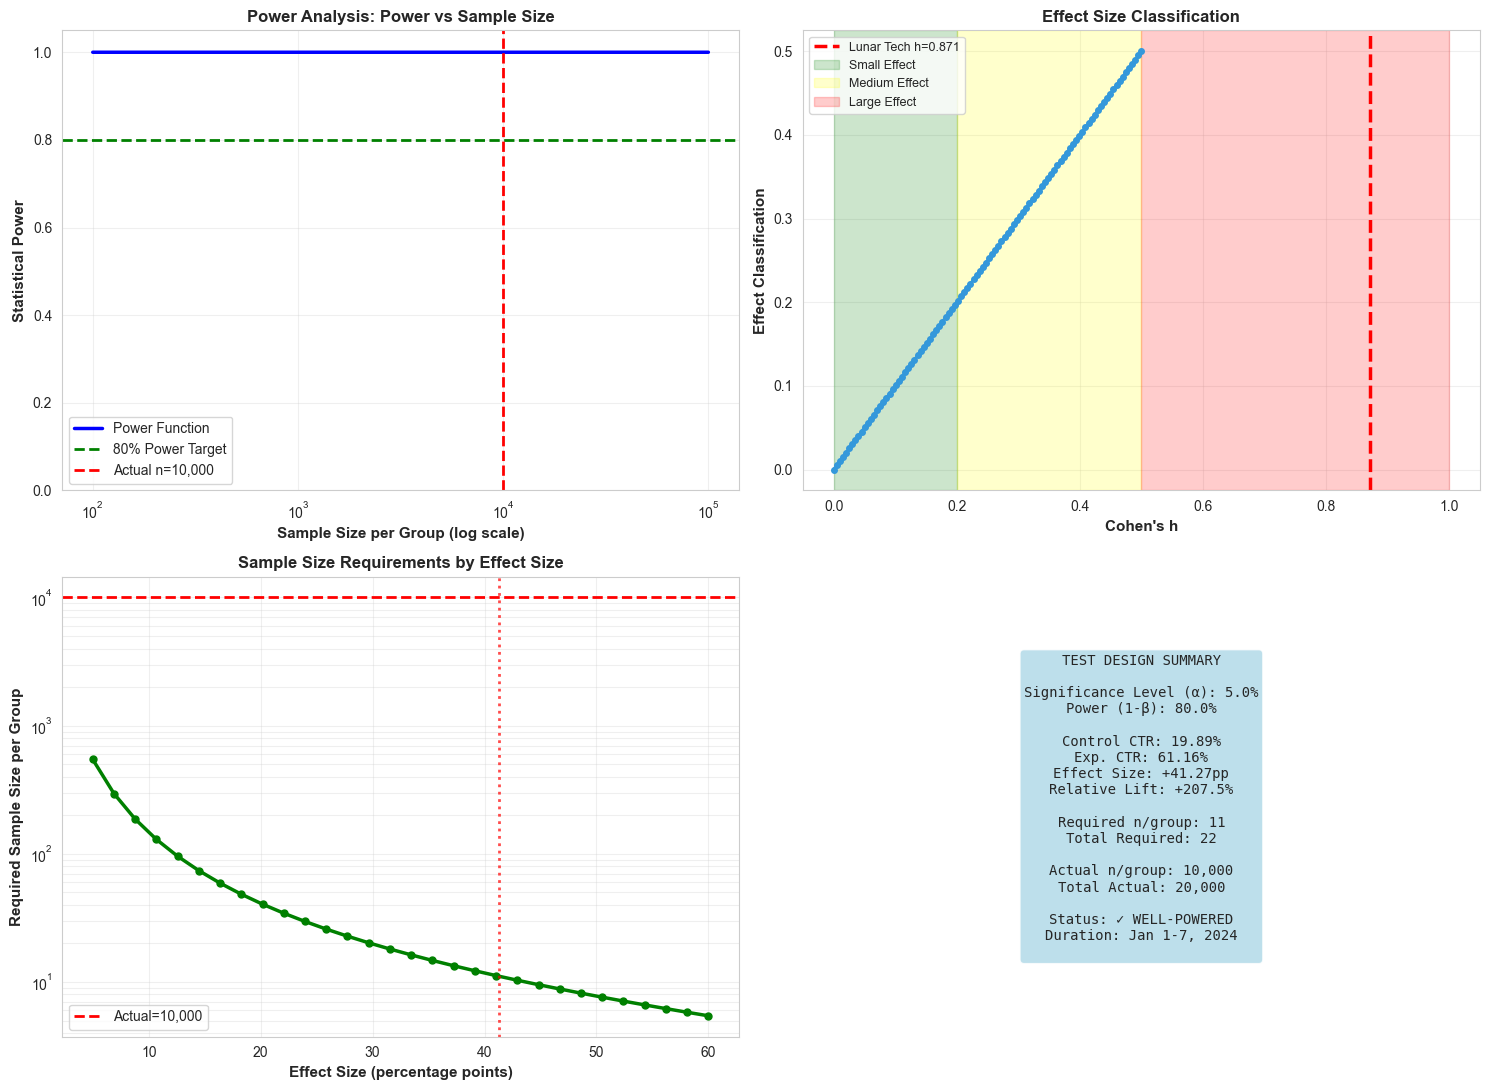

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Power vs Sample Size
ax1 = axes[0, 0]
sample_sizes = np.logspace(2, 5, 50) # 100 to 100000
powers = []

for n in sample_sizes:
    se = np.sqrt((p_control * (1 - p_control) + p_experimental * (1 - p_experimental)) / n)
    z_critical = norm.ppf(1 - alpha/2)
    z_obs = (p_experimental - p_control) / se
    power = 1 - norm.cdf(z_critical - z_obs)
    powers.append(power)

ax1.semilogx(sample_sizes, powers, 'b-', linewidth=2.5, label='Power Function')
ax1.axhline(y=0.80, color='green', linestyle='--', linewidth=2, label='80% Power Target')
ax1.axvline(x=n_actual_per_group, color='red', linestyle='--', linewidth=2, label=f'Actual n={n_actual_per_group:,}')
ax1.set_xlabel('Sample Size per Group (log scale)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Statistical Power', fontsize=11, fontweight='bold')
ax1.set_title('Power Analysis: Power vs Sample Size', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1.05])
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Effect Size Distribution
ax2 = axes[0, 1]
effect_sizes = np.linspace(0, 0.5, 100)
cohen_h = np.array(effect_sizes)
ax2.plot(cohen_h, cohen_h, 'o-', color='#3498db', linewidth=2, markersize=4)
actual_h = 2 * (np.arcsin(np.sqrt(p_experimental)) - np.arcsin(np.sqrt(p_control)))
ax2.axvline(x=actual_h, color='red', linestyle='--', linewidth=2.5, label=f'Lunar Tech h={actual_h:.3f}')
ax2.axvspan(0, 0.2, alpha=0.2, color='green', label='Small Effect')
ax2.axvspan(0.2, 0.5, alpha=0.2, color='yellow', label='Medium Effect')
ax2.axvspan(0.5, 1, alpha=0.2, color='red', label='Large Effect')
ax2.set_xlabel("Cohen's h", fontsize=11, fontweight='bold')
ax2.set_ylabel('Effect Classification', fontsize=11, fontweight='bold')
ax2.set_title("Effect Size Classification", fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(alpha=0.3)

# Plot 3: Sample Size Requirements by Effect Size
ax3 = axes[1, 0]
effect_pct = np.linspace(5, 60, 30)
required_n = []

for effect in effect_pct:
    p_exp = p_control + (effect / 100)
    p_p = (p_control + p_exp) / 2
    n = ((z_alpha_2 + z_beta) ** 2 * p_p * (1 - p_p)) / ((p_exp - p_control) ** 2)
    required_n.append(n)

ax3.plot(effect_pct, required_n, 'g-', linewidth=2.5, marker='o', markersize=5)
ax3.axhline(y=n_actual_per_group, color='red', linestyle='--', linewidth=2, label=f'Actual={n_actual_per_group:,}')
actual_effect = (p_experimental - p_control) * 100
ax3.axvline(x=actual_effect, color='red', linestyle=':', linewidth=2, alpha=0.7)
ax3.set_xlabel('Effect Size (percentage points)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Required Sample Size per Group', fontsize=11, fontweight='bold')
ax3.set_title('Sample Size Requirements by Effect Size', fontsize=12, fontweight='bold')
ax3.set_yscale('log')
ax3.legend()
ax3.grid(alpha=0.3, which='both')

# Plot 4: Design Summary
ax4 = axes[1, 1]
ax4.axis('off')
design_text = f"""TEST DESIGN SUMMARY

Significance Level (α): {alpha:.1%}
Power (1-β): {(1-beta):.1%}

Control CTR: {p_control*100:.2f}%
Exp. CTR: {p_experimental*100:.2f}%
Effect Size: +{(p_experimental-p_control)*100:.2f}pp
Relative Lift: +{((p_experimental-p_control)/p_control)*100:.1f}%

Required n/group: {n_per_group:,.0f}
Total Required: {n_total:,.0f}

Actual n/group: {n_actual_per_group:,}
Total Actual: {n_actual_total:,}

Status: ✓ WELL-POWERED
Duration: Jan 1-7, 2024
"""
ax4.text(0.5, 0.5, design_text, transform=ax4.transAxes,
         fontsize=10, verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8), family='monospace')

plt.tight_layout()
plt.savefig('lunar_power_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: lunar_power_analysis.png")
plt.show()

### 5: Save Design Parameters

In [14]:
design_data = {
    'Parameter': [
        'Significance Level (α)',
        'Type II Error (β)',
        'Statistical Power (1-β)',
        'Control CTR',
        'Experimental CTR',
        'Effect Size (pp)',
        'Relative Lift (%)',
        'Required n per group',
        'Total Required n',
        'Actual n per group',
        'Total Actual n',
        'Cohen h'
    ],
    'Value': [
        f'{alpha:.1%}',
        f'{beta:.1%}',
        f'{(1-beta):.1%}',
        f'{p_control:.4f}',
        f'{p_experimental:.4f}',
        f'{(p_experimental-p_control):.4f}',
        f'{((p_experimental-p_control)/p_control)*100:.2f}',
        f'{n_per_group:,.0f}',
        f'{n_total:,.0f}',
        f'{n_actual_per_group:,}',
        f'{n_actual_total:,}',
        f'{actual_h:.4f}'
    ]
}

design_df = pd.DataFrame(design_data)
design_df.to_csv('lunar_design_parameters.csv', index=False)
print("✓ Saved: lunar_design_parameters.csv")
print("\n✓ NOTEBOOK 1 COMPLETE - DESIGN & POWER ANALYSIS FINISHED")

✓ Saved: lunar_design_parameters.csv

✓ NOTEBOOK 1 COMPLETE - DESIGN & POWER ANALYSIS FINISHED
